# Model Building

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,accuracy_score,recall_score,r2_score,precision_score,roc_auc_score,confusion_matrix,\
f1_score,cohen_kappa_score,roc_curve,roc_auc_score

from imblearn.over_sampling import SMOTE

import warnings 
warnings.filterwarnings("ignore")

## Splitting the dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent

train_df = pd.read_csv(PROJECT_ROOT / "data" / "train_sample_2024.csv")
test_df  = pd.read_csv(PROJECT_ROOT / "data" / "test_sample_2025.csv")

In [3]:
print(train_df.shape)
print(test_df.shape)

(200001, 25)
(100001, 25)


## Data Preprocessing


In [4]:
# Extract hour
train_df['DEP_HOUR'] = train_df['CRS_DEP_TIME'] // 100
test_df['DEP_HOUR'] = test_df['CRS_DEP_TIME'] // 100

# Create time-of-day category
def time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

train_df['DEP_PERIOD'] = train_df['DEP_HOUR'].apply(time_period)
test_df['DEP_PERIOD'] = test_df['DEP_HOUR'].apply(time_period)

In [5]:
# Applying N-1 encoding
train_cat = ['DEP_PERIOD', 'MKT_UNIQUE_CARRIER']
train_df = pd.get_dummies(train_df, columns=train_cat, drop_first=True)
test_df = pd.get_dummies(test_df, columns=train_cat, drop_first=True)

In [6]:
feature_cols = [
    'QUARTER',
    'MONTH',
    'DAY_OF_WEEK',
    'DEP_HOUR',
    'ORIGIN_AIRPORT_ID',
    'DEST_AIRPORT_ID',
    'DISTANCE',
    'TAXI_OUT'
]
dep_period_dummies = [col for col in train_df.columns if col.startswith('DEP_PERIOD_')]
carrier_dummies = [col for col in train_df.columns if col.startswith('MKT_UNIQUE_CARRIER_')]

feature_cols = feature_cols + dep_period_dummies + carrier_dummies


test_num=test_df[feature_cols].select_dtypes(include=np.number).columns.to_list()
test_cat=test_df[feature_cols].select_dtypes(include=object).columns.to_list()

In [7]:
# Create x and y for train
x_train = train_df[feature_cols]
y_train = train_df['OPERATIONAL_RISK']

# Create x and y for test
x_test = test_df[feature_cols]
y_test=test_df['OPERATIONAL_RISK']

In [8]:
# # Appling SMOTE to balance the class
# smote = SMOTE(random_state=42)

# x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# print("Before SMOTE:\n", y_train.value_counts())
# print("After SMOTE:\n", y_train_smote.value_counts())

In [9]:
summary = pd.DataFrame(columns=['Name','Accuracy','Precision','Recall','F1_Score','ROC_AUC','Cohen_Kappa'])

def metrics(name, y_test, ypred_hard, ypred_soft):
    global summary

    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_test, ypred_hard))
    print('------------------------------------------------------------')

    acc = round(accuracy_score(y_test, ypred_hard), 2)
    pre = round(precision_score(y_test, ypred_hard), 2)
    rec = round(recall_score(y_test, ypred_hard), 2)
    f1  = round(f1_score(y_test, ypred_hard), 2)
    auc = round(roc_auc_score(y_test, ypred_soft), 2)
    reliability = round(cohen_kappa_score(y_test, ypred_hard), 2)

    result = pd.DataFrame({
        'Name':[name],
        'Accuracy':[acc],
        'Precision':[pre],
        'Recall':[rec],
        'F1_Score':[f1],
        'ROC_AUC':[auc],
        'Cohen_Kappa':[reliability]
    })

    summary = pd.concat([summary, result], ignore_index=True)
    return summary

## Baseline Model - Logistic Regression

In [10]:
model1 = LogisticRegression(random_state=42)
model1.fit(x_train, y_train)

ypred_soft_1 = model1.predict_proba(x_test)[:,1]
ypred_hard_1 = (ypred_soft_1 > 0.5).astype(int)

summary = metrics(
    "Baseline Logistic",
    y_test,
    ypred_hard_1,
    ypred_soft_1
)


Classification Report for Baseline Logistic:

              precision    recall  f1-score   support

           0       0.80      0.98      0.88     78229
           1       0.71      0.13      0.22     21772

    accuracy                           0.80    100001
   macro avg       0.76      0.56      0.55    100001
weighted avg       0.78      0.80      0.74    100001

------------------------------------------------------------


In [11]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17


## Model 2 - Logistic Regression with class weights


In [12]:
model2 = LogisticRegression(class_weight='balanced', random_state=42)
model2.fit(x_train, y_train)

ypred_soft_2 = model2.predict_proba(x_test)[:,1]
ypred_hard_2 = (ypred_soft_2 > 0.5).astype(int)

summary = metrics(
    "Logistic class",
    y_test,
    ypred_hard_2,
    ypred_soft_2
)



Classification Report for Logistic class:

              precision    recall  f1-score   support

           0       0.86      0.63      0.73     78229
           1       0.32      0.63      0.43     21772

    accuracy                           0.63    100001
   macro avg       0.59      0.63      0.58    100001
weighted avg       0.74      0.63      0.66    100001

------------------------------------------------------------


In [13]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19


## Model 3 - Desicison Tree with class weights

In [14]:
model3 = DecisionTreeClassifier(class_weight='balanced',random_state=42)
model3.fit(x_train, y_train)

ypred_soft_3 = model3.predict_proba(x_test)[:,1]
ypred_hard_3 = (ypred_soft_3 > 0.3).astype(int)

summary = metrics(
    "Decision Tree",
    y_test,
    ypred_hard_3,
    ypred_soft_3
)


Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.81      0.82      0.81     78229
           1       0.33      0.32      0.33     21772

    accuracy                           0.71    100001
   macro avg       0.57      0.57      0.57    100001
weighted avg       0.71      0.71      0.71    100001

------------------------------------------------------------


In [15]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14


## Model 4 - Random Forest with class weights

In [16]:
model4 = RandomForestClassifier(class_weight='balanced',random_state=42)
model4.fit(x_train, y_train)

ypred_soft_4 = model4.predict_proba(x_test)[:,1]
ypred_hard_4 = (ypred_soft_4 > 0.5).astype(int)

summary = metrics(
    "Random Forest",
    y_test,
    ypred_hard_4,
    ypred_soft_4
)


Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.81      0.97      0.88     78229
           1       0.63      0.19      0.29     21772

    accuracy                           0.80    100001
   macro avg       0.72      0.58      0.59    100001
weighted avg       0.77      0.80      0.75    100001

------------------------------------------------------------


In [17]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21


## Model 5 - Random Forest Tune-1

In [18]:
params={
    'n_estimators':[150,200],
    'max_depth':[20,30],
    'min_samples_split':[2,3],
    'min_samples_leaf':[2,3]
}

gscv1=GridSearchCV(estimator=RandomForestClassifier(),param_grid=params,cv=5,scoring = 'recall').fit(x_train,y_train)

gscv1.best_params_

{'max_depth': 30,
 'min_samples_leaf': 2,
 'min_samples_split': 3,
 'n_estimators': 150}

In [19]:
model5 = RandomForestClassifier(class_weight='balanced',random_state=42,max_depth=30,min_samples_leaf=2,min_samples_split=2,n_estimators=150)
model5.fit(x_train, y_train)

ypred_soft_5 = model5.predict_proba(x_test)[:,1]
ypred_hard_5 = (ypred_soft_5 > 0.5).astype(int)

summary = metrics(
    "Random Forest-T1",
    y_test,
    ypred_hard_5,
    ypred_soft_5
)


Classification Report for Random Forest-T1:

              precision    recall  f1-score   support

           0       0.83      0.92      0.87     78229
           1       0.52      0.30      0.38     21772

    accuracy                           0.79    100001
   macro avg       0.67      0.61      0.63    100001
weighted avg       0.76      0.79      0.77    100001

------------------------------------------------------------


In [20]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27


## Model 6 - Random Forest Tune-2

In [21]:
params={
    'n_estimators':[200,250],
    'max_depth':[15,20],
    'min_samples_split':[2,4],
    'min_samples_leaf':[3,4]
}

gscv2=GridSearchCV(estimator=RandomForestClassifier(),param_grid=params,cv=5,scoring = 'recall').fit(x_train,y_train)

gscv2.best_params_

{'max_depth': 20,
 'min_samples_leaf': 3,
 'min_samples_split': 4,
 'n_estimators': 200}

In [22]:
model6 = RandomForestClassifier(class_weight='balanced',random_state=42,max_depth=20,min_samples_leaf=3,min_samples_split=4,n_estimators=250)
model6.fit(x_train, y_train)

ypred_soft_6 = model6.predict_proba(x_test)[:,1]
ypred_hard_6 = (ypred_soft_6 > 0.5).astype(int)

summary = metrics(
    "Random Forest-T2",
    y_test,
    ypred_hard_6,
    ypred_soft_6
)


Classification Report for Random Forest-T2:

              precision    recall  f1-score   support

           0       0.84      0.84      0.84     78229
           1       0.44      0.44      0.44     21772

    accuracy                           0.75    100001
   macro avg       0.64      0.64      0.64    100001
weighted avg       0.75      0.75      0.75    100001

------------------------------------------------------------


In [23]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28


In [24]:
fpr, tpr, thresholds = roc_curve(y_test, ypred_soft_6)

# Youden Index
youden_index = tpr - fpr

# best threshold
best_index = np.argmax(youden_index)
best_threshold = thresholds[best_index]

print("Best Threshold :", round(best_threshold,2))
print("Youden Index :", round(youden_index[best_index],2))

Best Threshold : 0.4
Youden Index : 0.3


## Model 6 - Random Forest T-2 Different Threshold

In [25]:
model6 = RandomForestClassifier(class_weight='balanced',random_state=42,max_depth=20,min_samples_leaf=3,min_samples_split=4,n_estimators=250)
model6.fit(x_train, y_train)

ypred_soft_6 = model6.predict_proba(x_test)[:,1]
ypred_hard_6 = (ypred_soft_6 > 0.40).astype(int)

summary = metrics(
    "Random Forest-TH",
    y_test,
    ypred_hard_6,
    ypred_soft_6
)


Classification Report for Random Forest-TH:

              precision    recall  f1-score   support

           0       0.86      0.70      0.77     78229
           1       0.36      0.60      0.45     21772

    accuracy                           0.68    100001
   macro avg       0.61      0.65      0.61    100001
weighted avg       0.75      0.68      0.70    100001

------------------------------------------------------------


In [26]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28
6,Random Forest-TH,0.68,0.36,0.6,0.45,0.71,0.24


## Model 7 - Random Forest Tune-3


In [27]:
params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [12, 15, 18, 22],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

rscv3 = RandomizedSearchCV(
            estimator=RandomForestClassifier(),
            param_distributions=params,
            n_iter=30,          
            cv=5,
            scoring='recall',
            random_state=42,
            n_jobs=-1
        ).fit(x_train, y_train)

rscv3.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 12,
 'class_weight': 'balanced'}

In [28]:
model7 = RandomForestClassifier(class_weight='balanced',random_state=42,max_depth=12,min_samples_leaf=2,min_samples_split=2,n_estimators=200,max_features='sqrt')
model7.fit(x_train, y_train)

ypred_soft_7 = model7.predict_proba(x_test)[:,1]
ypred_hard_7 = (ypred_soft_7 > 0.5).astype(int)

summary = metrics(
    "Random Forest-T3",
    y_test,
    ypred_hard_7,
    ypred_soft_7
)


Classification Report for Random Forest-T3:

              precision    recall  f1-score   support

           0       0.86      0.71      0.78     78229
           1       0.36      0.60      0.45     21772

    accuracy                           0.68    100001
   macro avg       0.61      0.65      0.61    100001
weighted avg       0.75      0.68      0.71    100001

------------------------------------------------------------


In [29]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28
6,Random Forest-TH,0.68,0.36,0.6,0.45,0.71,0.24
7,Random Forest-T3,0.68,0.36,0.6,0.45,0.71,0.24


## Model 8 - XGBoost

In [30]:
model8 = XGBClassifier()

model8.fit(x_train, y_train)
ypred_soft_8 = model8.predict_proba(x_test)[:,1]
ypred_hard_8 = (ypred_soft_8 > 0.5).astype(int)
summary = metrics(
    "XGBoost",
    y_test,
    ypred_hard_8,
    ypred_soft_8
)



Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.81      0.97      0.89     78229
           1       0.66      0.19      0.30     21772

    accuracy                           0.80    100001
   macro avg       0.74      0.58      0.59    100001
weighted avg       0.78      0.80      0.76    100001

------------------------------------------------------------


In [31]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28
6,Random Forest-TH,0.68,0.36,0.6,0.45,0.71,0.24
7,Random Forest-T3,0.68,0.36,0.6,0.45,0.71,0.24
8,XGBoost,0.8,0.66,0.19,0.3,0.72,0.22


## Model 9 - XGBoost Tune 1

In [32]:
params = {
    'n_estimators': [200, 250, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'gamma': [0, 1, 3, 5],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, 3, 5]   
}

rscv_xgb = RandomizedSearchCV(
                estimator=XGBClassifier(
                        objective='binary:logistic',
                        eval_metric='logloss',
                        use_label_encoder=False
                ),
                param_distributions=params,
                n_iter=40,
                scoring='recall',
                cv=5,
                random_state=42,
                n_jobs=-1
            ).fit(x_train, y_train)

rscv_xgb.best_params_

{'subsample': 0.8,
 'scale_pos_weight': 5,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 6,
 'learning_rate': 0.01,
 'gamma': 3}

In [33]:
model9 = XGBClassifier(
    subsample=0.8,
    scale_pos_weight=5,
    n_estimators=200,
    min_child_weight=5,
    max_depth=6,
    learning_rate=0.01,
    gamma=3
)


model9.fit(x_train, y_train)
ypred_soft_9 = model9.predict_proba(x_test)[:,1]
ypred_hard_9 = (ypred_soft_9 > 0.5).astype(int)
summary = metrics(
    "XGBoost-T1",
    y_test,
    ypred_hard_9,
    ypred_soft_9
)



Classification Report for XGBoost-T1:

              precision    recall  f1-score   support

           0       0.89      0.50      0.64     78229
           1       0.30      0.78      0.43     21772

    accuracy                           0.56    100001
   macro avg       0.60      0.64      0.54    100001
weighted avg       0.76      0.56      0.59    100001

------------------------------------------------------------


In [34]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28
6,Random Forest-TH,0.68,0.36,0.6,0.45,0.71,0.24
7,Random Forest-T3,0.68,0.36,0.6,0.45,0.71,0.24
8,XGBoost,0.8,0.66,0.19,0.3,0.72,0.22
9,XGBoost-T1,0.56,0.3,0.78,0.43,0.72,0.18


## Model 10 - XGBoost - Tune 2

In [35]:
params_balanced = {
    'n_estimators': [300, 400, 500],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.75, 0.8, 0.85],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [1, 2, 3],
    'min_child_weight': [3, 5, 7],
    'scale_pos_weight': [2, 3, 4]   
}

rscv_xgb_bal = RandomizedSearchCV(
        estimator=XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42
        ),
        param_distributions=params_balanced,
        n_iter=50,
        scoring='f1',     
        cv=5,
        n_jobs=-1,
        random_state=42
).fit(x_train, y_train)

rscv_xgb_bal.best_params_

{'subsample': 0.85,
 'scale_pos_weight': 3,
 'n_estimators': 500,
 'min_child_weight': 5,
 'max_depth': 6,
 'learning_rate': 0.07,
 'gamma': 1,
 'colsample_bytree': 0.7}

In [36]:
model10 = XGBClassifier(
    subsample=0.85,
    scale_pos_weight=3,
    n_estimators=500,
    min_child_weight=5,
    max_depth=6,
    learning_rate=0.07,
    gamma=1,
    colsample_bytree=0.7
)


model10.fit(x_train, y_train)
ypred_soft_10 = model10.predict_proba(x_test)[:,1]
ypred_hard_10 = (ypred_soft_10 > 0.5).astype(int)
summary = metrics(
    "XGBoost-T2",
    y_test,
    ypred_hard_10,
    ypred_soft_10
)



Classification Report for XGBoost-T2:

              precision    recall  f1-score   support

           0       0.85      0.79      0.82     78229
           1       0.41      0.52      0.46     21772

    accuracy                           0.73    100001
   macro avg       0.63      0.65      0.64    100001
weighted avg       0.76      0.73      0.74    100001

------------------------------------------------------------


In [37]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28
6,Random Forest-TH,0.68,0.36,0.6,0.45,0.71,0.24
7,Random Forest-T3,0.68,0.36,0.6,0.45,0.71,0.24
8,XGBoost,0.8,0.66,0.19,0.3,0.72,0.22
9,XGBoost-T1,0.56,0.3,0.78,0.43,0.72,0.18


In [38]:
fpr, tpr, thresholds = roc_curve(y_test, ypred_soft_10)

# Youden Index
youden_index = tpr - fpr

# best threshold
best_index = np.argmax(youden_index)
best_threshold = thresholds[best_index]

print("Best Threshold :", round(best_threshold,2))
print("Youden Index :", round(youden_index[best_index],2))

Best Threshold : 0.45
Youden Index : 0.31


In [39]:
model10 = XGBClassifier(
    subsample=0.85,
    scale_pos_weight=3,
    n_estimators=500,
    min_child_weight=5,
    max_depth=6,
    learning_rate=0.07,
    gamma=1,
    colsample_bytree=0.7
)


model10.fit(x_train, y_train)
ypred_soft_10 = model10.predict_proba(x_test)[:,1]
ypred_hard_10 = (ypred_soft_10 > 0.45).astype(int)
summary = metrics(
    "XGBoost-TH",
    y_test,
    ypred_hard_10,
    ypred_soft_10
)



Classification Report for XGBoost-TH:

              precision    recall  f1-score   support

           0       0.86      0.72      0.79     78229
           1       0.37      0.59      0.46     21772

    accuracy                           0.69    100001
   macro avg       0.62      0.66      0.62    100001
weighted avg       0.76      0.69      0.71    100001

------------------------------------------------------------


In [40]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, ypred_soft_10)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold for F1:", round(best_threshold,2))
print("Best F1:", round(f1_scores[best_index],2))

Best Threshold for F1: 0.49
Best F1: 0.46


In [41]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28
6,Random Forest-TH,0.68,0.36,0.6,0.45,0.71,0.24
7,Random Forest-T3,0.68,0.36,0.6,0.45,0.71,0.24
8,XGBoost,0.8,0.66,0.19,0.3,0.72,0.22
9,XGBoost-T1,0.56,0.3,0.78,0.43,0.72,0.18


In [42]:
model10 = XGBClassifier(
    subsample=0.85,
    scale_pos_weight=3,
    n_estimators=500,
    min_child_weight=5,
    max_depth=6,
    learning_rate=0.07,
    gamma=1,
    colsample_bytree=0.7
)


model10.fit(x_train, y_train)
ypred_soft_10 = model10.predict_proba(x_test)[:,1]
ypred_hard_10 = (ypred_soft_10 > 0.46).astype(int)
summary = metrics(
    "XGBoost-TH2",
    y_test,
    ypred_hard_10,
    ypred_soft_10
)



Classification Report for XGBoost-TH2:

              precision    recall  f1-score   support

           0       0.86      0.73      0.79     78229
           1       0.38      0.58      0.46     21772

    accuracy                           0.70    100001
   macro avg       0.62      0.66      0.62    100001
weighted avg       0.76      0.70      0.72    100001

------------------------------------------------------------


In [43]:
summary

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Baseline Logistic,0.8,0.71,0.13,0.22,0.68,0.17
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14
3,Random Forest,0.8,0.63,0.19,0.29,0.69,0.21
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28
6,Random Forest-TH,0.68,0.36,0.6,0.45,0.71,0.24
7,Random Forest-T3,0.68,0.36,0.6,0.45,0.71,0.24
8,XGBoost,0.8,0.66,0.19,0.3,0.72,0.22
9,XGBoost-T1,0.56,0.3,0.78,0.43,0.72,0.18


In [44]:
summary.sort_values(by='F1_Score',ascending=False)

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
10,XGBoost-T2,0.73,0.41,0.52,0.46,0.72,0.28
11,XGBoost-TH,0.69,0.37,0.59,0.46,0.72,0.26
12,XGBoost-TH2,0.7,0.38,0.58,0.46,0.72,0.26
6,Random Forest-TH,0.68,0.36,0.6,0.45,0.71,0.24
7,Random Forest-T3,0.68,0.36,0.6,0.45,0.71,0.24
5,Random Forest-T2,0.75,0.44,0.44,0.44,0.71,0.28
1,Logistic class,0.63,0.32,0.63,0.43,0.69,0.19
9,XGBoost-T1,0.56,0.3,0.78,0.43,0.72,0.18
4,Random Forest-T1,0.79,0.52,0.3,0.38,0.71,0.27
2,Decision Tree,0.71,0.33,0.32,0.33,0.57,0.14


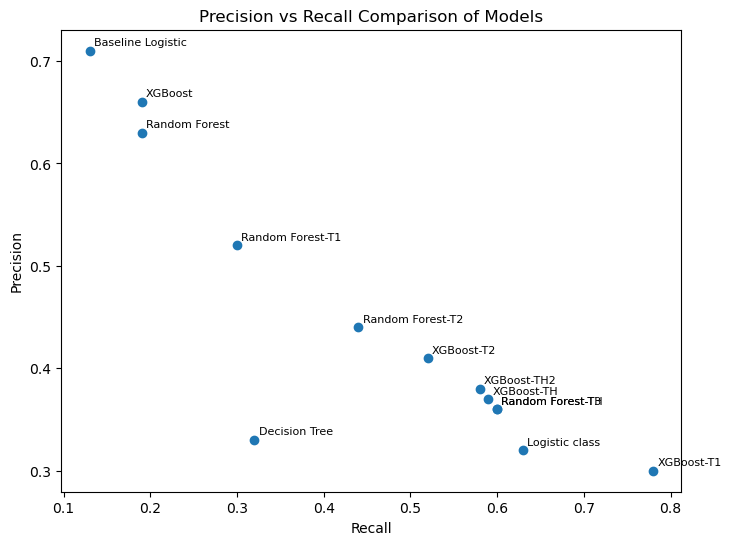

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(summary['Recall'], summary['Precision'])

for i, txt in enumerate(summary['Name']):
    plt.text(summary['Recall'][i]+0.005,
             summary['Precision'][i]+0.005,
             txt, fontsize=8)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Comparison of Models")

plt.show()

## Extracting the model for deployment

In [46]:
import joblib
# Save the trained model and feature columns
joblib.dump((model10, feature_cols), "xgboost_model10_with_features.joblib")
print("Model and features saved as xgboost_model10_with_features.joblib")

Model and features saved as xgboost_model10_with_features.joblib
